<a href="https://colab.research.google.com/github/Kubojah-Dan/kuboja-codeboosters-2026/blob/main/DAY3/Day3_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##WEB SCRAPPING USING API KEY FROM WEATHER MAP



In [ ]:
#============================
# Configure API Settings
#============================

API_KEY='####################################'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'

CITIES = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']

print(f"API Key: {API_KEY}")
print(f"Base URL: {BASE_URL}")
print(f"Cities: {CITIES}")

API Key: 42ad7d03f8adbf41e032d9ecdceca4d6
Base URL: https://api.openweathermap.org/data/2.5/weather
Cities: ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [ ]:
#==================================
# EXTRACT: Call API for each City
#==================================

import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q' : city,
      'appid' : api_key,
      'units' : 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    response.raise_for_status()
    data = response.json()
    return {
        'city' : data['name'],
        'feels_like': round(data['main']['feels_like'], 1),
        'icon' : data['weather'][0]['icon'],
        'description' : data['weather'][0]['description'],
        'temperature' : round(data['main']['temp'], 1),
        'humidity' : data['main']['humidity'],
        'wind_speed' : data['wind']['speed'],
    }
  except requests.exceptions.RequestException as e:
    print(f"Error fetching weather data for {city}: {e}")

  except requests.exceptions.Timeout:
    print(f"Timeout fetching weather data for {city}")

  except requests.exceptions.HTTPError as e:
    print(f"HTTP error fetching weather data for {city}: {e}")

print("Calling Weather API....")
weather_records = []

for city in CITIES:
  print(f' Fetching: {city}...', end='')
  weather_data = fetch_weather(city, API_KEY)
  if weather_data:
    weather_records.append(weather_data)
    print(weather_data)

print(f"Successfully Fetched: {len(weather_records)}")

Calling Weather API....
 Fetching: Mumbai...{'city': 'Mumbai', 'feels_like': 40.2, 'icon': '50d', 'description': 'haze', 'temperature': 34.0, 'humidity': 55, 'wind_speed': 6.17}
 Fetching: Delhi...{'city': 'Delhi', 'feels_like': 41.1, 'icon': '01d', 'description': 'clear sky', 'temperature': 44.0, 'humidity': 10, 'wind_speed': 7.72}
 Fetching: Bangalore...{'city': 'Bengaluru', 'feels_like': 31.9, 'icon': '03d', 'description': 'scattered clouds', 'temperature': 29.9, 'humidity': 56, 'wind_speed': 7.6}
 Fetching: Chennai...{'city': 'Chennai', 'feels_like': 43.1, 'icon': '02d', 'description': 'few clouds', 'temperature': 36.1, 'humidity': 52, 'wind_speed': 4.12}
 Fetching: Hyderabad...{'city': 'Hyderabad', 'feels_like': 32.1, 'icon': '04d', 'description': 'broken clouds', 'temperature': 30.2, 'humidity': 54, 'wind_speed': 7.72}
 Fetching: Kolkata...{'city': 'Kolkata', 'feels_like': 37.6, 'icon': '50d', 'description': 'haze', 'temperature': 32.0, 'humidity': 62, 'wind_speed': 5.14}
 Fetchi

In [10]:
import pandas as pd

weather_df = pd.DataFrame(weather_records)

print("Weather DataFrame Created:")
print(weather_df.to_string(index=False))
print(f"\nShape of DataFrame: {weather_df.shape}")
print(f"\nMissing Values: {weather_df.isna().sum().sum()}")
print(f"\nData Types: \n{weather_df.dtypes}")

Weather DataFrame Created:
     city  feels_like icon      description  temperature  humidity  wind_speed
   Mumbai        40.2  50d             haze         34.0        55        6.17
    Delhi        41.1  01d        clear sky         44.0        10        7.72
Bengaluru        31.9  03d scattered clouds         29.9        56        7.60
  Chennai        43.1  02d       few clouds         36.1        52        4.12
Hyderabad        32.1  04d    broken clouds         30.2        54        7.72
  Kolkata        37.6  50d             haze         32.0        62        5.14
     Pune        36.8  04d  overcast clouds         36.9        27        3.76
   Jaipur        41.8  50d             haze         41.6        20        4.63

Shape of DataFrame: (8, 7)

Missing Values: 0

Data Types: 
city            object
feels_like     float64
icon            object
description     object
temperature    float64
humidity         int64
wind_speed     float64
dtype: object


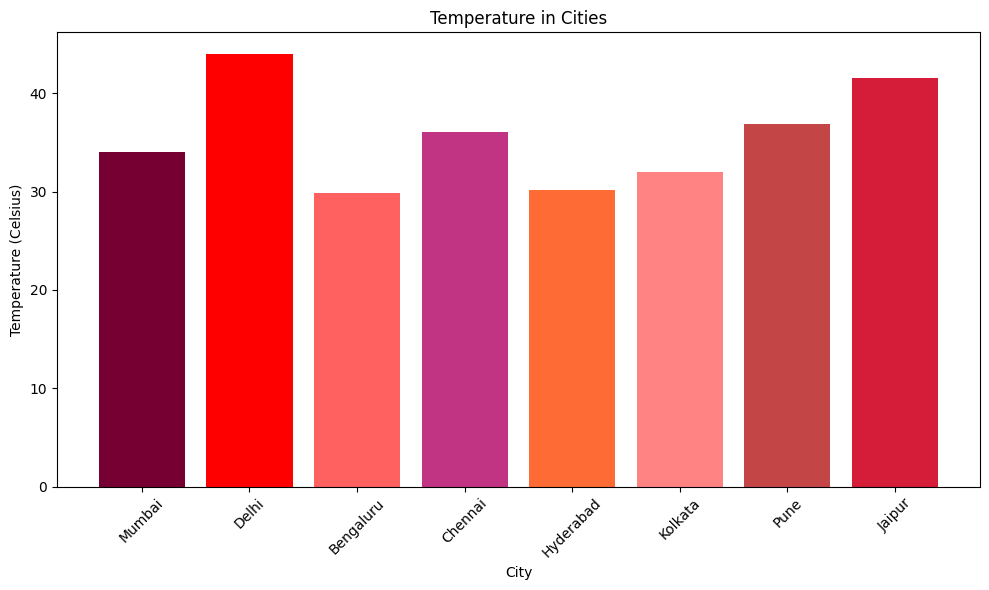

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

bar_colors = ['#760031', '#FF0000', '#FF6060', '#C13383', '#FF6B35', '#FF8383', '#C44545', '#D51C39']

plt.figure(figsize=(10, 6))
plt.bar(weather_df['city'], weather_df['temperature'], color=bar_colors)
plt.xlabel('City')
plt.ylabel('Temperature (Celsius)')
plt.title('Temperature in Cities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()